In [1]:
dataLocation = "C:\\Users\\Hoang Le\\Dropbox (Princeton)\\QuantumRegister\\PersonalFolders\\Hoang\\KerrCatData\\220103_TAFC1_B3\\T1_vs_flux\\"

import os
import sys
sys.path.append("C:\\Users\\Hoang Le" + "\\Dropbox (Princeton)\\QuantumRegister\\codebases\\hangerTraceAnalysis\\")

import hangerTraceAnalysis as ta
import numpy as np
import warnings
import matplotlib.cbook
warnings.filterwarnings("ignore", category=matplotlib.cbook.mplDeprecation)
from IPython.display import display, Image, Markdown
import matplotlib.pyplot as plt

import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from scipy.optimize import curve_fit

# %matplotlib notebook
pi = np.pi
from mpl_toolkits.axes_grid1 import make_axes_locatable

hellloooo
hi


In [2]:
# %matplotlib inline
from matplotlib import cm
import cmocean
import matplotlib as mpl
cmpocean_solar = cm.get_cmap(cmocean.cm.solar, 16)(np.linspace(0, 1, 16))
cmpocean_tarn = cm.get_cmap(cmocean.cm.tarn, 6)(np.linspace(0, 1, 6))
cmp_magma = cm.get_cmap('magma', 256)(np.linspace(0, 1, 256))
%matplotlib notebook

# figure properties
font_size         = 15
line_width        = 0.3
major_tick_length = 2 
minor_tick_length = 1
axes_color        = [0, 0, 0, 1]            
params = {
          'text.usetex'         : False,
          'font.size'           : font_size,
          'legend.fontsize'     : font_size,
          'axes.labelsize'      : font_size,         
          'axes.linewidth'      : line_width,
          'axes.labelcolor'     : axes_color,
          'axes.titlesize'      : font_size,
          'axes.titlepad'       : 2,
          'legend.frameon'      : False,
          'legend.handletextpad': 0.2,
          'legend.handlelength' : 1.0,
          'legend.labelspacing' : 0.2,
          # x ticks
          'xtick.color'        : axes_color,
          'xtick.direction'    : 'in',
          'xtick.labelsize'    : font_size,          
          'xtick.major.width'  : line_width,
          'xtick.minor.width'  : line_width,
          'xtick.major.size'   : major_tick_length,
          'xtick.minor.size'   : minor_tick_length,
          'xtick.bottom'       : True,
          'xtick.major.bottom' : True,
          'xtick.minor.bottom' : True,
          'xtick.top'          : True,
          'xtick.major.top'    : True,
          'xtick.minor.top'    : True,
           # y ticks
          'ytick.color'        : axes_color,
          'ytick.direction'    : 'in',
          'ytick.labelsize'    : font_size,          
          'ytick.major.width'  : line_width,
          'ytick.minor.width'  : line_width,
          'ytick.major.size'   : major_tick_length,
          'ytick.minor.size'   : minor_tick_length,
          'ytick.left'         : True,
          'ytick.major.left'   : True,
          'ytick.minor.left'   : True,
          'ytick.right'        : True,
          'ytick.major.right'  : True,
          'ytick.minor.right'  : True,          
          }
mpl.rcParams.update(params)
pi = np.pi; h = 6.626e-34; hbar = h/pi/2; e = 1.602e-19; phi0 = h/(2*e); GHz = 1e9; nH = 1e-9; MHz = 1e6; fF = 1e-15
mpl.rc('font',family='Arial')

In [3]:
def T1expo(x, a, T1, c):
    return a * np.exp(-x/T1) + c

def volt2flux(volt):
    return -0.5*volt + 0.1125

class T1trace:
    def __init__(self, dataLocation, x_filename):
        self.x_filename = x_filename
        self.datetime = x_filename[5:24]
        x_address = dataLocation + x_filename
        x_df = pd.read_csv(x_address, header=None)
        x = np.array(x_df.values); x = x[0]
        self.x = x
        
        for filename in os.listdir(dataLocation):
            if 'T1_y' in filename and not 'pdf' in filename and self.datetime in filename:
                self.y_filename = filename
                y_address = dataLocation + filename
                y_df = pd.read_csv(y_address, header=None)
                y = np.array(y_df.values); y = y[0]
                multiplier = 1/y[0]; y = y*multiplier
                self.y = y
        
        popt, pcov = curve_fit(T1expo, x, y); perr = np.sqrt(np.diag(pcov))
        T_1 = popt[1]; T_1_sigma = perr[1]
        self.T_1 = T_1; self.T_1_sigma = T_1_sigma
        
        fluxVolt = np.int(x_filename[25:-6])
        if fluxVolt == -273:
            fluxVolt = -275
        elif fluxVolt == -274:
            fluxVolt = -275
        elif fluxVolt == -301:
            fluxVolt = -300
        elif fluxVolt == -326:
            fluxVolt = -325
        self.flux = np.round(volt2flux(fluxVolt*0.001),5)
        print(self.flux)
#         print(self.T_1)

#         fig, ax = plt.subplots(figsize=(4,3))
#         ax.plot(x, y)
#         ax.plot(x, T1expo(x, *popt))
#         ax.set_xlabel(r'Time ($\mu$s)')
#         ax.set_ylabel(r'Qubit population (a.u.)')
#         ax.set_title("$T_1$ = %.2f $\mu$s $\pm$ %.2f $\mu$s" % (T_1, T_1_sigma))
#         fig.tight_layout()

class fluxPoint:
    def __init__(self, flux, fluxDict):
        self.flux = flux
        
        mean_T1 = np.sum([tr.T_1/tr.T_1_sigma**2 for tr in fluxDict[flux]]) / np.sum([1/tr.T_1_sigma**2 for tr in fluxDict[flux]])
        sigma_T1 = 1/np.sqrt(np.sum([1/tr.T_1_sigma**2 for tr in fluxDict[flux]]))
        
        self.mean_T1 = np.round(mean_T1,2)
        self.sigma_T1 = np.round(sigma_T1,2)

# CAV VS FLUX

In [4]:
dataLocation = "C:\\Users\\Hoang Le\\Dropbox (Princeton)\\QuantumRegister\\PersonalFolders\\Hoang\\KerrCatData\\220103_TAFC1_B3\\TAFC1_B3_quarterFlux_thruCL\\"

In [5]:
x_filename = 'cavTrans_sweepFlux_freq_2022_01_10_21_30_44.csv'
x_address = dataLocation + x_filename
x_df = pd.read_csv(x_address, header=None)
x = np.array(x_df.values); x = x[0]

y_filename = 'cavTrans_sweepFlux_yokoV_2022_01_10_21_30_44.csv'
y_address = dataLocation + y_filename
y_df = pd.read_csv(y_address, header=None)
y = np.array(y_df.values); y = y[0]
y = -0.5*y + 0.117

z_filename = 'cavTrans_sweepFlux_results_2022_01_10_21_30_44.csv'
z_address = dataLocation + z_filename
z_df = pd.read_csv(z_address, header=None)
z = np.array(z_df.values); z = z[0]

x2_filename = 'cavTrans_sweepFlux_freq_2022_01_10_22_31_47.csv'
x2_address = dataLocation + x2_filename
x2_df = pd.read_csv(x2_address, header=None)
x2 = np.array(x2_df.values); x2 = x2[0]

y2_filename = 'cavTrans_sweepFlux_yokoV_2022_01_10_22_31_47.csv'
y2_address = dataLocation + y2_filename
y2_df = pd.read_csv(y2_address, header=None)
y2 = np.array(y2_df.values); y2 = y2[0]
y2 = -0.5*y2 + 0.117

z2_filename = 'cavTrans_sweepFlux_results_2022_01_10_22_31_47.csv'
z2_address = dataLocation + z2_filename
z2_df = pd.read_csv(z2_address, header=None)
z2 = np.array(z2_df.values); z2 = z2[0]

<IPython.core.display.Javascript object>


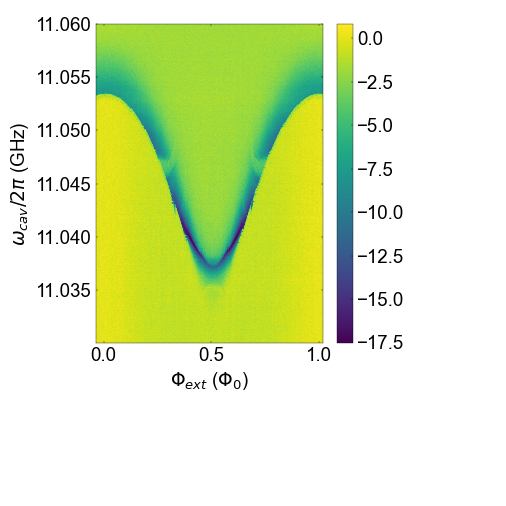

In [6]:
znew = np.zeros((len(x), len(y)))
for jjj in range(len(y)):
    znew[:,jjj] = z[jjj*len(x):jjj*len(x) + len(x)]
    
znew2 = np.zeros((len(x2), len(y2)))
for jjj in range(len(y2)):
    znew2[:,jjj] = z2[jjj*len(x2):jjj*len(x2) + len(x2)]
    
fig = plt.subplots(figsize=(5,5))
ax = plt.subplot(111, xlabel="Resonator Frequency (MHz)", ylabel=r'2$\pi \Phi_{ext}/\Phi_0$')

shape = np.shape(znew)
for iii in range(shape[1]):
    bkg = np.average(znew[0:100,iii])
    znew[:,iii] = znew[:,iii] - bkg
    
shape2 = np.shape(znew2)
for iii in range(shape2[1]):
    bkg = np.average(znew2[0:100,iii])
    znew2[:,iii] = znew2[:,iii] - bkg 

xplot = y; yplot = x; xplot = xplot[0:138]; znew = znew[:,0:138]
xplot2 = y2; yplot2 = x2;

xall = np.concatenate((xplot,xplot2))
yall = yplot/1e3
zall = np.concatenate((znew,znew2), axis=1)

for jjj in np.linspace(len(yall)-1, 0, len(yall)):
    jjj = int(jjj)
    if jjj > 370:
        zall[jjj,:] = zall[jjj,:] - np.mean(zall[jjj,0:20])
    else:
        zall[jjj,:] = zall[jjj,:] - np.mean(zall[jjj,130:150])
        zall[jjj,:] = zall[jjj,:] - (np.mean(zall[jjj,130:150]) - np.mean(zall[371,130:150]))

im = ax.pcolormesh(xall,yall,zall)

ax.set_ylabel(r'$\omega_{cav}/2\pi$ (GHz)', fontsize=15, fontname="Arial")
ax.set_xlabel(r'$\Phi_{ext}$ ($\Phi_0$)', fontsize=15, fontname="Arial")
ax.tick_params(axis='both', which='major', labelsize=15)
plt.xticks(fontname = "Arial"); plt.yticks(fontname = "Arial")
plt.tight_layout()

cb = plt.colorbar(im)
cb.ax.tick_params(labelsize=15)
s = "Ampl. (a.u.)"

<IPython.core.display.Javascript object>


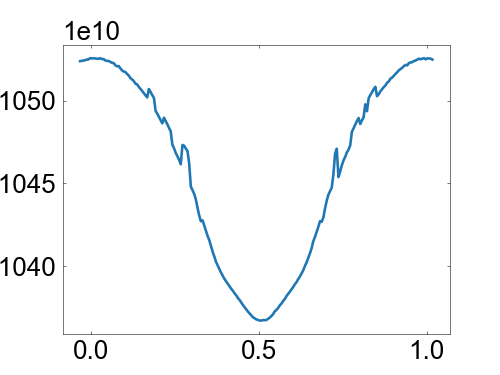

In [46]:
# # fit cavity transmission
# f0 = []
# def hanger_fit(xDat, freq0, QInt, Qc, asymm, offset):
#     Q0 = 1 / (1 / QInt + 1 / Qc)
#     return 20*np.log10(np.abs(1 - (Q0/Qc - 2j*Q0 *asymm/(2 * np.pi * freq0))/(1 + 2j*Q0*(xDat - freq0)/freq0))) + offset

# for iii in range(len(xall)):
#     xfit = yall*1e9
#     yfit = zall[:,iii]
    
#     p0=[11.04e9,1e3,1e3,0,0]; 
#     lb = [-np.inf, -np.inf, -np.inf, -np.inf, -np.inf]; ub = [np.inf,np.inf,np.inf,np.inf,np.inf]
#     popt, pcov = curve_fit(hanger_fit, xfit, yfit, p0=p0, bounds=(lb,ub)); perr = np.sqrt(np.diag(pcov));
    
#     f0.append(popt[0])
# #     print(iii)
    
# #     fig, ax = plt.subplots()
# #     ax.plot(xfit, yfit)
# #     ax.plot(xfit, hanger_fit(xfit, *popt))

# fig, ax = plt.subplots(figsize=(4,3))
# f0 = np.array(f0)
# ax.plot(xall,f0)

# #very bad fit
    

<IPython.core.display.Javascript object>


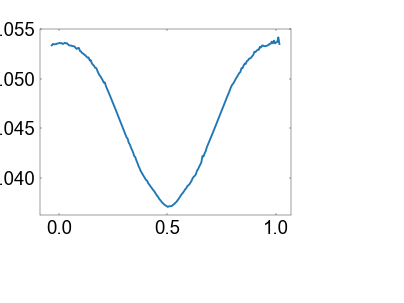

In [7]:
# just take the min of amp in the spectrum to be fcav, corrected for weird points by using the fit
fcav = [yall[np.argmin(zall[:,iii])] for iii in range(len(xall))]
fig,ax = plt.subplots(figsize=(4,3))

def sinusoid(x, A,T,phi,c):
    return A*np.cos(2*pi/T*x + phi) + c

p0=[0.01,1,0,11.04]; 
lb = [-np.inf, -np.inf, -np.inf, -np.inf]; ub = [np.inf,np.inf,np.inf,np.inf]
popt, pcov = curve_fit(sinusoid, xall, fcav, p0=p0, bounds=(lb,ub)); perr = np.sqrt(np.diag(pcov));
fcav_fit = sinusoid(xall, *popt)

fcav[50:70] = fcav_fit[50:70]
fcav[145:165] = fcav_fit[145:165]
# ax.plot(xall[50:70],fcav[50:70])
# ax.plot(xall[145:165],fcav[145:165])

ax.plot(xall,fcav)
fcav = np.array(fcav)
# ax.plot(xall, fcav_fit)

In [9]:
# fcav.tofile('fcav_y'+'.csv', sep=',', format='%10.9f')
# xall.tofile('fcav_x'+'.csv', sep=',', format='%10.9f')

### Two chi vs flux

In [67]:
x_filename = 'fcav_x.csv'
x_address = x_filename
x_df = pd.read_csv(x_address, header=None)
x1 = np.array(x_df.values); x1 = x1[0]

filename = 'fcav_y.csv'
address = filename
df = pd.read_csv(address, header=None)
fcav = np.array(df.values); fcav = fcav[0]*1e9

filename = 'w01_y_TAFC1_B3_2.csv'
address = filename
df = pd.read_csv(address, header=None)
f01 = np.array(df.values); f01 = f01[0]*1e9

filename = 'w02_y_TAFC1_B3_2.csv'
address = filename
df = pd.read_csv(address, header=None)
f02 = np.array(df.values); f02 = f02[0]*1e9

filename = 'w00_y_TAFC1_B3_2.csv'
address = filename
df = pd.read_csv(address, header=None)
f00 = np.array(df.values); f00 = f00[0]*1e9

alpha = f02-2*f01+f00
delta = fcav - f01
Ec = 39.7*MHz; cr = pi/(2*2*pi*fcav*50) #452.554*fF; 
beta = 0.164395 #pi/(2*2*pi*fcav*50) #
M01 = 1/4 * np.sqrt(1 + f01/Ec)
Vrms = np.sqrt(h*fcav/(2*cr))
g = 2/h*beta*e*Vrms*M01
twoChi = 2*g**2*alpha/delta/(delta-alpha) * fcav/f01

wr0 = np.mean(fcav - g**2/delta)
print(wr0)

11016221943.092667


<IPython.core.display.Javascript object>


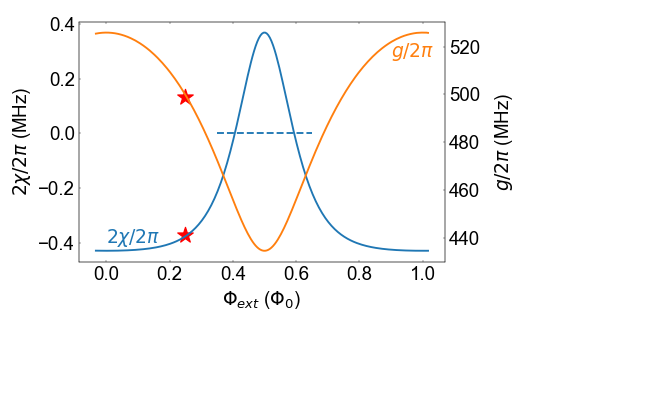

In [68]:
fig,ax = plt.subplots(figsize=(6.5,4))
ax.plot(x1, twoChi/1e6, label=r'$2\chi/2\pi$', color='C0')

ax.set_ylabel(r'$2\chi/2\pi$ (MHz)', fontsize=15, fontname="Arial")
ax.set_xlabel(r'$\Phi_{ext}$ ($\Phi_0$)', fontsize=15, fontname="Arial")
ax.tick_params(axis='both', which='major', labelsize=15)
plt.xticks(fontname = "Arial"); plt.yticks(fontname = "Arial")
ax.hlines(y=0,xmin=0.35,xmax=0.65, linestyle='--', color='C0')
ax.scatter(0.25, -0.37, s=169, color='red', marker="*")

rightAx = ax.twinx()
rightAx.plot(x1, g/1e6, color='C1')
rightAx.set_ylabel(r'$g/2\pi$ (MHz)', fontsize=15, fontname="Arial", labelpad=10)
rightAx.scatter(0.25, 499, s=169, color='red', marker="*")

s = r'$2\chi/2\pi$'
ax.text(0, -0.4, s , fontsize=15, fontname="Arial", color='C0');
s = r'$g/2\pi$'
ax.text(0.9, 0.28, s , fontsize=15, fontname="Arial", color='C1');
# rightAx.set_ylim((0,1000))
plt.tight_layout()
# plt.savefig('chi_g_vsflux.png',dpi=600)

<IPython.core.display.Javascript object>


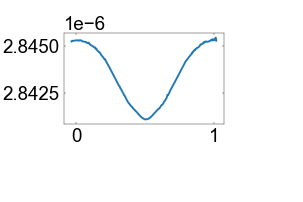

In [60]:
fig,ax = plt.subplots(figsize=(3,2))
ax.plot(x1,Vrms)
plt.tight_layout()

In [58]:
cr.max()/fF

453.0183708009727

<IPython.core.display.Javascript object>


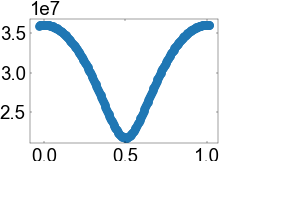

[1.17584650e+00 1.10108564e+10]


<IPython.core.display.Javascript object>


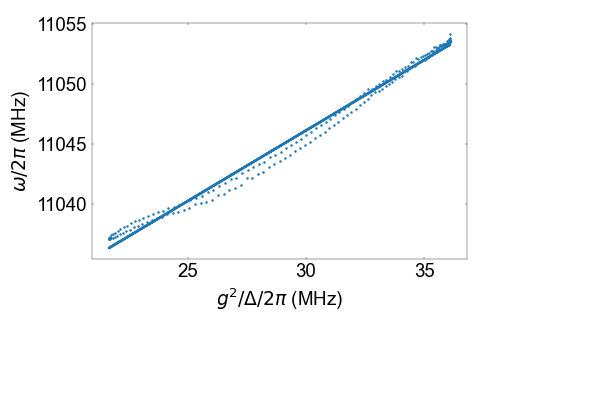

1.175846503910511
11010856405.793041


array([8.15394175e-03, 2.51976107e+05])

In [12]:
fig, ax = plt.subplots(figsize=(3,2))
# ax.scatter(xall, fcav-fcav[0])
ax.scatter(xall, g**2/delta)
# fig, ax = plt.subplots(figsize=(3,2))
# ax.scatter(xall, delta)
# fig, ax = plt.subplots(figsize=(5,3))
fakechi = g**2/delta
deltafcav = fcav - fcav.min()

def linear(x,a,b):
    return a*x + b

popt, pcov = curve_fit(linear, fakechi, fcav); perr = np.sqrt(np.diag(pcov))
print(popt)
a = popt[0]; b = popt[1]

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(fakechi/1e6, fcav/1e6, s=1)
ax.plot(fakechi/1e6, linear(fakechi, *popt)/1e6, linewidth=2)

ax.set_ylabel(r'$\omega/2\pi$ (MHz)', fontsize=15, fontname="Arial")
ax.set_xlabel(r'$g^2/\Delta/2\pi$ (MHz)', fontsize=15, fontname="Arial")
ax.tick_params(axis='both', which='major', labelsize=15)
plt.xticks(fontname = "Arial"); plt.yticks(fontname = "Arial")

plt.locator_params(axis='x', nbins=5)
plt.locator_params(axis='y', nbins=5)
plt.tight_layout()

# ax.scatter(xall, deltafcav - 1.17584645*fakechi)
# plt.savefig('cav_vs_fakechi.png', dpi=600)

print(a)
print(b)
perr

<IPython.core.display.Javascript object>


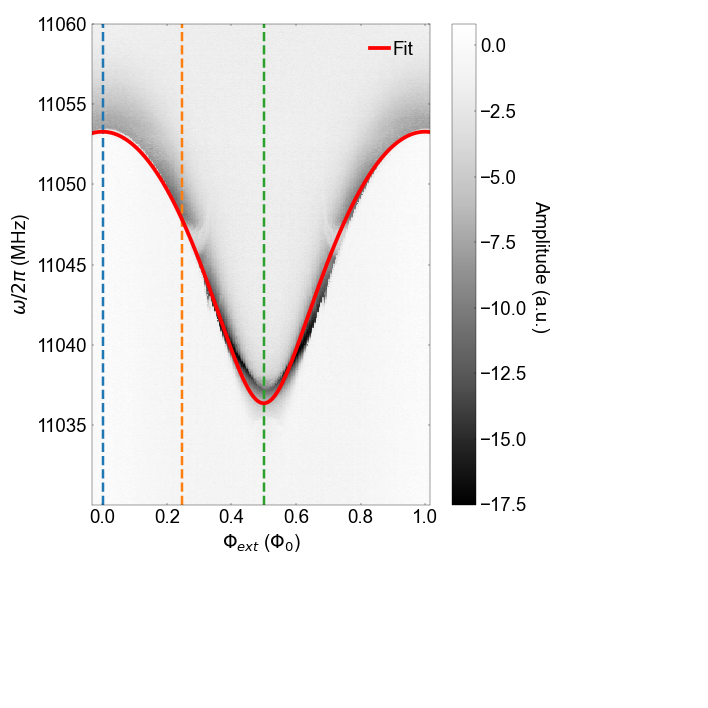

In [13]:
znew = np.zeros((len(x), len(y)))
for jjj in range(len(y)):
    znew[:,jjj] = z[jjj*len(x):jjj*len(x) + len(x)]
    
znew2 = np.zeros((len(x2), len(y2)))
for jjj in range(len(y2)):
    znew2[:,jjj] = z2[jjj*len(x2):jjj*len(x2) + len(x2)]
    
fig = plt.subplots(figsize=(7,7))
ax = plt.subplot(111, xlabel="Resonator Frequency (MHz)", ylabel=r'2$\pi \Phi_{ext}/\Phi_0$')

shape = np.shape(znew)
for iii in range(shape[1]):
    bkg = np.average(znew[0:100,iii])
    znew[:,iii] = znew[:,iii] - bkg
    
shape2 = np.shape(znew2)
for iii in range(shape2[1]):
    bkg = np.average(znew2[0:100,iii])
    znew2[:,iii] = znew2[:,iii] - bkg 

xplot = y; yplot = x; xplot = xplot[0:138]; znew = znew[:,0:138]
xplot2 = y2; yplot2 = x2;

xall = np.concatenate((xplot,xplot2))
yall = yplot
zall = np.concatenate((znew,znew2), axis=1)

for jjj in np.linspace(len(yall)-1, 0, len(yall)):
    jjj = int(jjj)
    if jjj > 370:
        zall[jjj,:] = zall[jjj,:] - np.mean(zall[jjj,0:20])
    else:
        zall[jjj,:] = zall[jjj,:] - np.mean(zall[jjj,130:150])
        zall[jjj,:] = zall[jjj,:] - (np.mean(zall[jjj,130:150]) - np.mean(zall[371,130:150]))

im = ax.pcolormesh(xall,yall,zall, cmap=plt.get_cmap('Greys_r'))
# ax.plot(xall, (wr0+g**2/delta)/1e6, color='red', label='Theory', linewidth=3)
ax.plot(xall, (b + a*fakechi)/1e6, color='red', label='Fit', linewidth=3)
# ax.plot(xall, fcav/1e9, color='red')

ax.set_ylabel(r'$\omega/2\pi$ (MHz)', fontsize=15, fontname="Arial")
ax.set_xlabel(r'$\Phi_{ext}$ ($\Phi_0$)', fontsize=15, fontname="Arial")
ax.tick_params(axis='both', which='major', labelsize=15)
plt.xticks(fontname = "Arial"); plt.yticks(fontname = "Arial")
plt.tight_layout()

cb = plt.colorbar(im)
cb.ax.tick_params(labelsize=15)

s = "Amplitude (a.u.)"
ax.text(1.33, 11041, s , fontsize=15, fontname="Arial", rotation=270);
ax.legend(loc="upper right", fontsize=15)

colorList = ['C0', 'C1', 'C2']

for iii, idx in enumerate([7,56,107]):
    ax.vlines(x = xall[idx], ymin=yall.min(), ymax=yall.max(), linewidth=2, linestyle='--', color=colorList[iii])

# plt.locator_params(axis='y', nbins=5)

plt.tight_layout()
# plt.savefig("cavityvsflux.png", dpi=600)

<IPython.core.display.Javascript object>


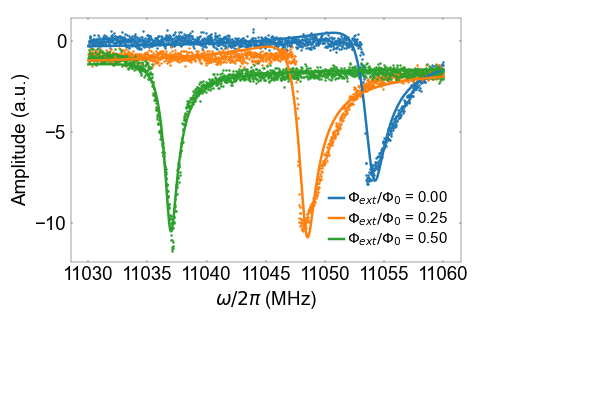

[ 1.10534040e+04  7.58230729e+03  7.27397757e+03 -4.21635498e+00
 -4.95235985e-01]
[ 1.10477353e+04  1.01485846e+04  6.28440228e+03 -4.47593715e+00
 -1.37378158e+00]
[ 1.10367303e+04  1.28892270e+04  7.30773978e+03 -1.49860594e+00
 -1.45025846e+00]


In [14]:
fig, ax = plt.subplots(figsize=(6,4))

def hanger_fit(xDat, freq0, QInt, Qc, asymm, offset):
    Q0 = 1 / (1 / QInt + 1 / Qc)
    return 20*np.log10(np.abs(1 - (Q0/Qc - 2j*Q0 *asymm/(2 * np.pi * freq0))/(1 + 2j*Q0*(xDat - freq0)/freq0))) + offset

for idx in [7,56,107]:
    xpts = yall; ypts = zall[:,idx]
    ax.scatter(xpts, ypts, s=1)
    
    p0=[11045,1e4,5e3,0,0]; 
    lb = [-np.inf, 0, 0, -np.inf, -np.inf]; ub = [np.inf,np.inf,np.inf,np.inf,np.inf]
    popt, pcov = curve_fit(hanger_fit, xpts, ypts, p0=p0, bounds=(lb,ub)); perr = np.sqrt(np.diag(pcov));
    print(popt)
    
    label=r'$\Phi_{ext}/\Phi_0$ = %.2f'  % (np.round(xall[idx],2))
    ax.plot(xpts, hanger_fit(xpts, *popt), linewidth=2, label=label)
    

# ax.scatter(x, y, label=r'$2\chi/2\pi$', color='C0', s=20)

ax.set_ylabel(r'Amplitude (a.u.)', fontsize=15, fontname="Arial")
ax.set_xlabel(r'$\omega/2\pi$ (MHz)', fontsize=15, fontname="Arial")
ax.tick_params(axis='both', which='major', labelsize=15)
plt.xticks(fontname = "Arial"); plt.yticks(fontname = "Arial")

plt.locator_params(axis='x', nbins=8)
plt.locator_params(axis='y', nbins=3)

ax.legend(loc='lower right', fontsize=12)


plt.tight_layout()
# plt.savefig('singleCavTrans.png',dpi=600)

# Single cav transmission

In [128]:
dataLocation = "C:\\Users\\Hoang Le\\Dropbox (Princeton)\\QuantumRegister\\PersonalFolders\\Hoang\\KerrCatData\\220103_TAFC1_B3\\TAFC1_B3_quarterFlux_thruCav\\"
x_filename = 'cavTrans_x_2022_01_07_18_01_23.csv'
x_address = dataLocation + x_filename
x_df = pd.read_csv(x_address, header=None)
x = np.array(x_df.values); x = x[0]

y_filename = 'cavTrans_y_2022_01_07_18_01_23.csv'
y_address = dataLocation + y_filename
y_df = pd.read_csv(y_address, header=None)
y = np.array(y_df.values); y = y[0]

<IPython.core.display.Javascript object>


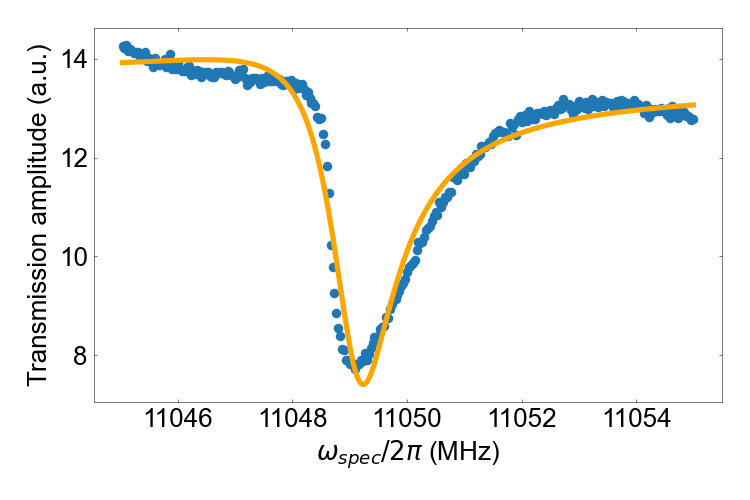

[ 1.10488824e+04  1.15128506e+04  1.25491479e+04 -1.67863734e+00
  1.35196882e+01]


In [144]:
fig,ax = plt.subplots(figsize=(6,4))
ax.scatter(x, y, label=r'$2\chi/2\pi$', color='C0', s=20)

ax.set_ylabel(r'Transmission amplitude (a.u.)', fontsize=15, fontname="Arial")
ax.set_xlabel(r'$\omega_{spec}/2\pi$ (MHz)', fontsize=15, fontname="Arial")
ax.tick_params(axis='both', which='major', labelsize=15)
plt.xticks(fontname = "Arial"); plt.yticks(fontname = "Arial")

def hanger_fit(xDat, freq0, QInt, Qc, asymm, offset):
    Q0 = 1 / (1 / QInt + 1 / Qc)
    return 20*np.log10(np.abs(1 - (Q0/Qc - 2j*Q0 *asymm/(2 * np.pi * freq0))/(1 + 2j*Q0*(xDat - freq0)/freq0))) + offset

    
p0=[11049,1e4,1e4,0,0]; 
lb = [-np.inf, -np.inf, -np.inf, -np.inf, -np.inf]; ub = [np.inf,np.inf,np.inf,np.inf,np.inf]
popt, pcov = curve_fit(hanger_fit, x, y, p0=p0, bounds=(lb,ub)); perr = np.sqrt(np.diag(pcov));
print(popt)

ax.plot(x, hanger_fit(x, *popt), color='orange', linewidth=3)

plt.tight_layout()
# plt.savefig('singleCavTrans.png',dpi=600)

# Stark - sweep freq

In [565]:
dataLocation = "C:\\Users\\Hoang Le\\Dropbox (Princeton)\\QuantumRegister\\PersonalFolders\\Hoang\\KerrCatData\\220103_TAFC1_B3\\TAFC1_B3_quarterFlux_thruCav\\"
x_filename = 'qubitSpecStark_sweepStarkFreq_freq_2022_01_16_09_00_23.csv'
x_address = dataLocation + x_filename
x_df = pd.read_csv(x_address, header=None)
x = np.array(x_df.values); x = x[0]

y_filename = 'qubitSpecStark_sweepStarkFreq_starkfreq_2022_01_16_09_00_23.csv'
y_address = dataLocation + y_filename
y_df = pd.read_csv(y_address, header=None)
y = np.array(y_df.values); y = y[0]

z_filename = 'qubitSpecStark_sweepStarkFreq_results_2022_01_16_09_00_23.csv'
z_address = dataLocation + z_filename
z_df = pd.read_csv(z_address, header=None)
z = np.array(z_df.values); z = z[0]
z = z.reshape((len(y), len(x)))

<IPython.core.display.Javascript object>


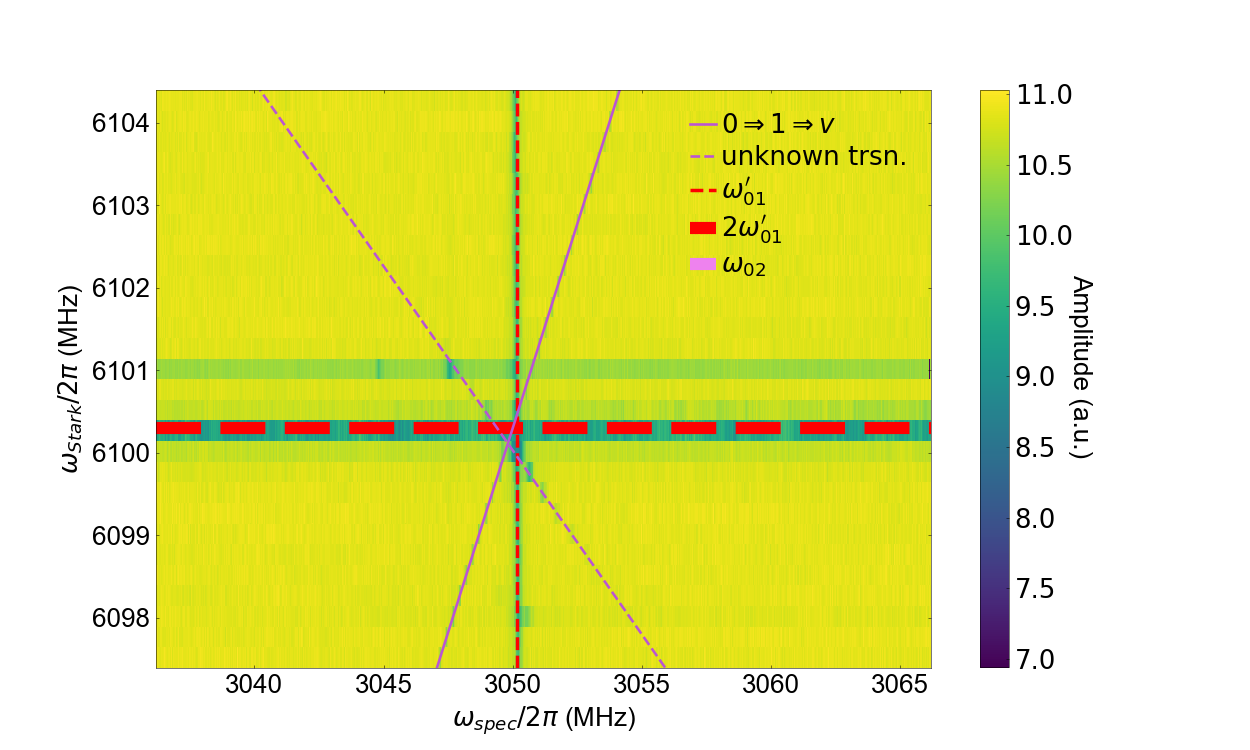

In [566]:
fig,ax = plt.subplots(figsize=(10,6))
im = ax.pcolormesh(x,y,z)
plt.colorbar(im)

w1 = 3050.18

def linear(x,a,b):
    return a*x + b

xplot1 = np.linspace(6097.4,6104.4,101)
yplot1 = linear(xplot1, 1.01, -1.02004*w1)
yplot2 = linear(xplot1, -2.24, 5.4797*w1)

ax.plot(yplot1, xplot1, color='mediumorchid', linewidth=1.5, linestyle='-', label="$0 \Rightarrow 1 \Rightarrow v$")
ax.plot(yplot2, xplot1, color='mediumorchid', linewidth=1.5, linestyle='--', label="unknown trsn.")
ax.vlines(x=w1, ymin=y.min(), ymax=y.max(), color='red', linewidth=2, linestyle='--', label="$\omega_{01}'$")
ax.hlines(y=1.99998*w1,xmin=x.min(), xmax=x.max(), color='red', linewidth=7, linestyle='--', label="$2\omega_{01}'$")
ax.hlines(y=6086,xmin=x.min(), xmax=x.max(), color='violet', linewidth=7, linestyle='--', label="$\omega_{02}$")
ax.set_ylim((y.min(), y.max()))

ax.set_ylabel(r'$\omega_{Stark}/2\pi$ (MHz)', fontsize=15, fontname="Arial");
ax.set_xlabel(r'$\omega_{spec}/2\pi$ (MHz)', fontsize=15, fontname="Arial");
ax.tick_params(axis='both', which='major', labelsize=15);
plt.xticks(fontname = "Arial"); plt.yticks(fontname = "Arial");

s = "Amplitude (a.u.)"
ax.text(3071.5,6100, s , fontsize=15, fontname="Arial", rotation=270);
ax.legend(loc="upper right")
# plt.savefig("qubitSpecStark_sweepStarkFreq_narrow.png", dpi=900)

In [567]:
print(y.min())
print(y.max())

6097.4
6104.4


In [569]:
dataLocation = "C:\\Users\\Hoang Le\\Dropbox (Princeton)\\QuantumRegister\\PersonalFolders\\Hoang\\KerrCatData\\220103_TAFC1_B3\\TAFC1_B3_quarterFlux_thruCav\\"
x_filename = 'qubitSpecStark_sweepStarkFreq_freq_2022_01_16_11_57_06.csv'
x_address = dataLocation + x_filename
x_df = pd.read_csv(x_address, header=None)
x = np.array(x_df.values); x = x[0]

y_filename = 'qubitSpecStark_sweepStarkFreq_starkfreq_2022_01_16_11_57_06.csv'
y_address = dataLocation + y_filename
y_df = pd.read_csv(y_address, header=None)
y = np.array(y_df.values); y = y[0]

z_filename = 'qubitSpecStark_sweepStarkFreq_results_2022_01_16_11_57_06.csv'
z_address = dataLocation + z_filename
z_df = pd.read_csv(z_address, header=None)
z = np.array(z_df.values); z = z[0]
z = z.reshape((len(y), len(x)))

y = y[1:]
z = z[1:,:]

<IPython.core.display.Javascript object>


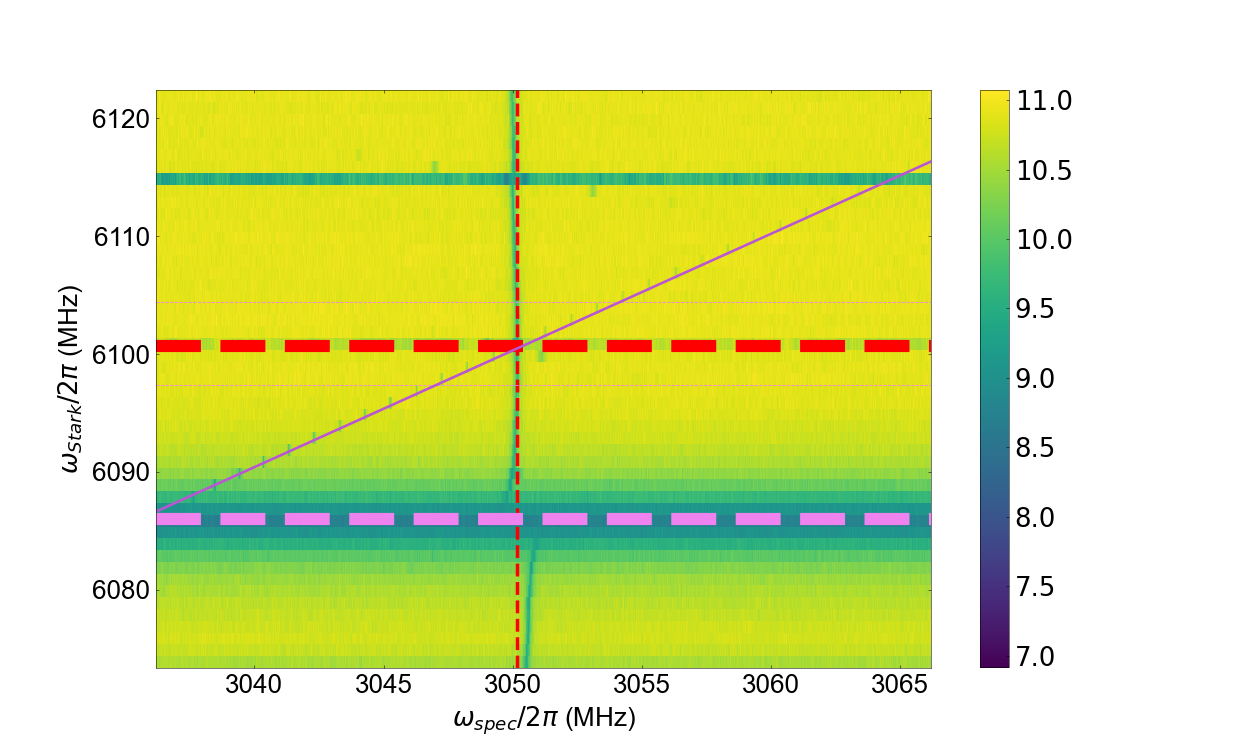

In [571]:
fig,ax = plt.subplots(figsize=(10,6))
im = ax.pcolormesh(x,y,z)
plt.colorbar(im)

w1 = 3050.18

def linear(x,a,b):
    return a*x + b

xplot1 = np.linspace(6086.7, 6116.3 ,101)
# yplot1 = linear(xplot1, 1, -1.0001*w1)
yplot1 = linear(xplot1, 1.01, -1.02004*w1)
yplot2 = linear(xplot1, -2.24, 5.4797*w1)

ax.plot(yplot1, xplot1, color='mediumorchid', linewidth=1.5, linestyle='-')
# ax.plot(yplot2, xplot1, color='mediumorchid', linewidth=1.5, linestyle='--')
ax.vlines(x=w1, ymin=y.min(), ymax=y.max(), color='red', linewidth=2, linestyle='--')
ax.hlines(y=2.0001*w1,xmin=x.min(), xmax=x.max(), color='red', linewidth=7, linestyle='--')
ax.hlines(y=6086,xmin=x.min(), xmax=x.max(), color='violet', linewidth=7, linestyle='--')
ax.hlines(y=6097.4,xmin=x.min(), xmax=x.max(), color='violet', linewidth=0.5, linestyle='--')
ax.hlines(y=6104.4,xmin=x.min(), xmax=x.max(), color='violet', linewidth=0.5, linestyle='--')

ax.set_ylabel(r'$\omega_{Stark}/2\pi$ (MHz)', fontsize=15, fontname="Arial");
ax.set_xlabel(r'$\omega_{spec}/2\pi$ (MHz)', fontsize=15, fontname="Arial");
ax.tick_params(axis='both', which='major', labelsize=15);
plt.xticks(fontname = "Arial"); plt.yticks(fontname = "Arial");

# s = "Amplitude (a.u.)"
# ax.text(3071.5,6090, s , fontsize=15, fontname="Arial", rotation=270);
# plt.savefig("qubitSpecStark_sweepStarkFreq_wide.png", dpi=900)

# Rabi under sqz

In [4]:
dataLocation = "C:\\Users\\Hoang Le\\Dropbox (Princeton)\\QuantumRegister\\PersonalFolders\\Hoang\\KerrCatData\\220103_TAFC1_B3\\TAFC1_B3_quarterFlux_thruCav\\"
x_filename = 'lenRabi_sweepSqzGain_time_2022_01_16_18_21_36.csv'
x_address = dataLocation + x_filename
x_df = pd.read_csv(x_address, header=None)
x = np.array(x_df.values); x = x[0]
x = x/1e3

y_filename = 'lenRabi_sweepSqzGain_sqzgain_2022_01_16_18_21_36.csv'
y_address = dataLocation + y_filename
y_df = pd.read_csv(y_address, header=None)
y = np.array(y_df.values); y = y[0]

z_filename = 'lenRabi_sweepSqzGain_results_2022_01_16_18_21_36.csv'
z_address = dataLocation + z_filename
z_df = pd.read_csv(z_address, header=None)
z = np.array(z_df.values); z = z[0]
z = z.reshape((len(y), len(x)))

z = (z - z.max())/(z.min() - z.max())

# 2022_01_16_18_21_36
# 2022_01_16_17_44_38

<IPython.core.display.Javascript object>


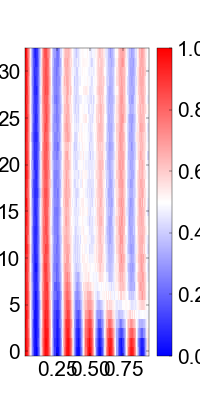

In [5]:
fig,ax = plt.subplots(figsize=(2,4))
im = ax.pcolormesh(x,y/1e3,z, cmap=plt.cm.get_cmap('bwr'), shading='auto', vmin=0, vmax=1)
plt.colorbar(im)

<IPython.core.display.Javascript object>


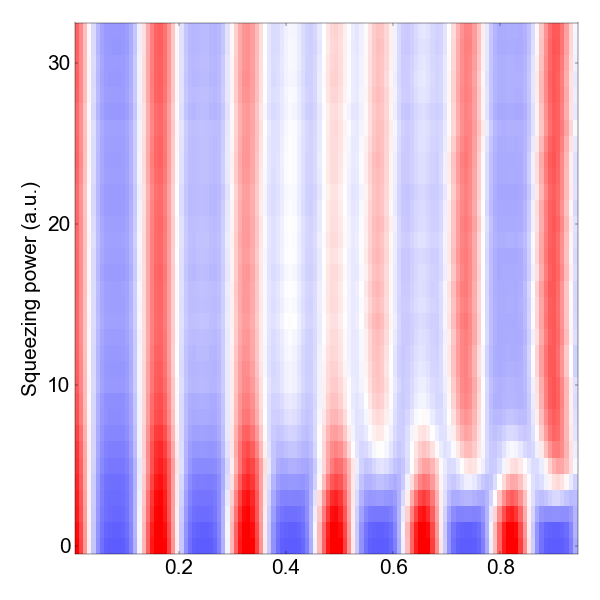

<IPython.core.display.Javascript object>


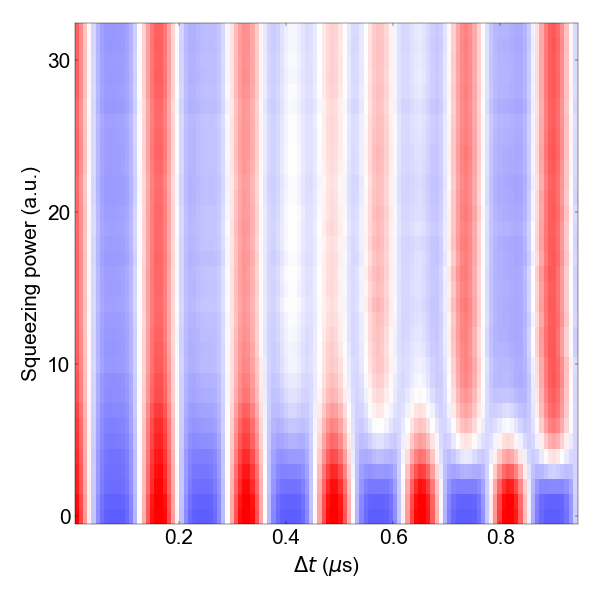

<IPython.core.display.Javascript object>


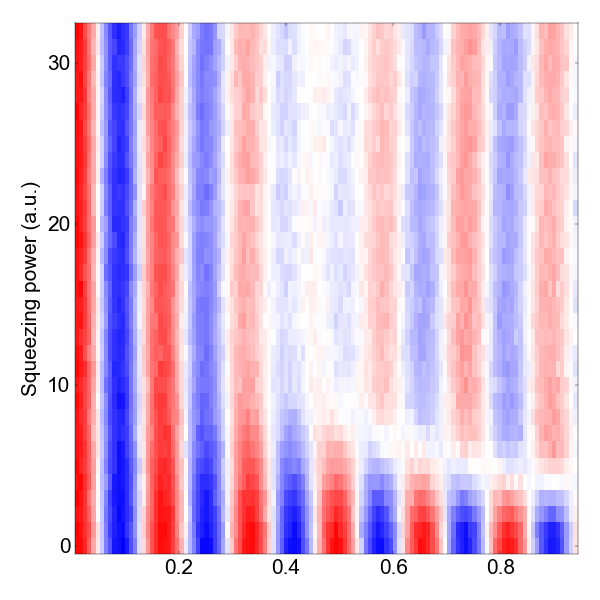

In [6]:
def rabi3(t, d, O, A, c):
    om = np.sqrt(d**2 + 8*O**2)
    return A*(1/4*((np.cos(om/2*t) + np.cos(d/2*t))**2 + (np.sin(d/2*t) + np.sin(om/2*t)*d/om)**2) ) + c

def rabi3full(t, d, O1, O2, A, c):
    o = np.sqrt((d-O2)**2 + 8*O1**2)
    o1 = d + 3*O2 + o
    ratio = (d + O2)/o
    diff = o - o1/2
    cos_o = np.cos(o*t); cos_o1by2 = np.cos(o1*t/2); cos_diff = np.cos(diff*t)
    return A*(1/8*((3 + cos_o + 2*cos_o1by2 + 2*cos_diff) + ratio**2*(1 - cos_o) + 2*ratio*(cos_o1by2 - cos_diff))) + c

result = []; result2 = []
popts = []; popts2 = []
perrs = []; perrs2 = []

# fig,ax = plt.subplots(figsize=(4,3))
for iii in range(len(y)):
    ynew = z[iii,:]
    
    p0 = (2*np.pi*0.5, 2*np.pi*6.18/np.sqrt(2), 0.5, 0.5)
    lb = [-np.inf, -np.inf, -np.inf, -np.inf]; ub = [np.inf,np.inf,np.inf,np.inf]
    popt, pcov = curve_fit(rabi3, x, ynew, p0=p0, bounds=(lb,ub)); perr = np.sqrt(np.diag(pcov));
    result_fitted = rabi3(x, *popt)
    result.append(result_fitted)
    popts.append(popt); perrs.append(perr)
    
    p02 = (2*np.pi*0.9, 2*np.pi*6.18/np.sqrt(2), 2*np.pi*0.001, 0.5, 0.5)
    lb = [2*np.pi*0.0, 2*np.pi*6.18/np.sqrt(2)*0.99, 2*np.pi*0.0, 0, -np.inf]
    ub = [2*np.pi*1.5, 2*np.pi*6.18/np.sqrt(2)*1.10, 2*np.pi*0.4, 2, np.inf]
    popt2, pcov2 = curve_fit(rabi3full, x, ynew, p0=p02, bounds=(lb,ub)); 
    perr2 = np.sqrt(np.diag(pcov2));
    result_fitted2 = rabi3full(x, *popt2)
    result2.append(result_fitted2)
    popts2.append(popt2); perrs2.append(perr2)
    
#     if iii < 10:
#         ax.scatter(x, ynew, s=3)
#         ax.plot(x, result_fitted)

result = np.array(result); popts = np.array(popts); perrs = np.array(perrs)
result = result.reshape((len(y), len(x))); popts = popts.reshape((len(y), 4)); perrs = perrs.reshape((len(y), 4))

result2 = np.array(result2); popts2 = np.array(popts2); perrs2 = np.array(perrs2)
result2 = result2.reshape((len(y), len(x))); popts2 = popts2.reshape((len(y), 5)); perrs2 = perrs2.reshape((len(y), 5)) 

# --------------------------------------------------------------------------------------------------------------
fig,ax = plt.subplots(figsize=(6,6))
im = ax.pcolormesh(x,y/1e3,result, cmap=plt.cm.get_cmap('bwr'), shading='auto', vmin=0, vmax=1)

ax.set_ylabel('Squeezing power (a.u.)', fontsize=15, fontname="Arial");
# ax.set_xlabel('$\Delta t$ ($\mu$s)', fontsize=15, fontname="Arial");
ax.tick_params(axis='both', which='major', labelsize=15);
plt.locator_params(axis='y', nbins=5)
plt.xticks(fontname = "Arial"); plt.yticks(fontname = "Arial");

# divider = make_axes_locatable(ax)
# cax = divider.append_axes("right", size="2%", pad=0.05)
# plt.colorbar(im, cax=cax)
# plt.xticks(fontname = "Arial"); plt.yticks(fontname = "Arial");

plt.tight_layout()
# ax.set_title("result")

# plt.savefig("rabivsgain_fitted1.png", dpi=900)

# --------------------------------------------------------------------------------------------------------------
fig,ax = plt.subplots(figsize=(6,6))
im = ax.pcolormesh(x,y/1e3,result2, cmap=plt.cm.get_cmap('bwr'), shading='auto', vmin=0, vmax=1)

ax.set_ylabel('Squeezing power (a.u.)', fontsize=15, fontname="Arial");
ax.set_xlabel('$\Delta t$ ($\mu$s)', fontsize=15, fontname="Arial");
ax.tick_params(axis='both', which='major', labelsize=15);
plt.locator_params(axis='y', nbins=5)
plt.xticks(fontname = "Arial"); plt.yticks(fontname = "Arial");

# plt.colorbar(im)
plt.tight_layout()
# ax.set_title("result2")

# plt.savefig("rabivsgain_fitted2.png", dpi=900)

# -------------------------------------------------------------------------------------------------------------

fig,ax = plt.subplots(figsize=(6,6))
im = ax.pcolormesh(x,y/1e3,z, cmap=plt.cm.get_cmap('bwr'), shading='auto', vmin=0, vmax=1)

ax.set_ylabel('Squeezing power (a.u.)', fontsize=15, fontname="Arial");
# ax.set_xlabel('$\Delta t$ ($\mu$s)', fontsize=15, fontname="Arial");
ax.tick_params(axis='both', which='major', labelsize=15);
plt.locator_params(axis='y', nbins=5)
plt.xticks(fontname = "Arial"); plt.yticks(fontname = "Arial");

plt.tight_layout()

# plt.savefig("rabivsgain_data.png", dpi=900)

# plt.colorbar(im)

<IPython.core.display.Javascript object>


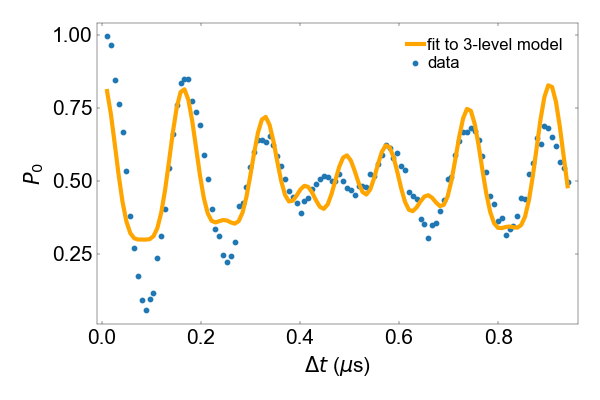

In [10]:
p0 = (2*np.pi*1.1, 2*np.pi*6.18/np.sqrt(2), 0.5, 0.5)
fig,ax = plt.subplots(figsize=(6,4))
ax.scatter(x, z[32,:], s = 10, label="data")
ax.plot(x, result[32,:],  linewidth=3, label="fit to 3-level model", color="orange")
# ax.plot(x, result2[32,:], linewidth=2, label="fit, incl. 0-2 trsn.", color="green")
ax.legend(loc = "upper right", fontsize=12)

ax.set_ylabel('$P_{0}$', fontsize=15, fontname="Arial");
ax.set_xlabel('$\Delta t$ ($\mu$s)', fontsize=15, fontname="Arial");
ax.tick_params(axis='both', which='major', labelsize=15);
plt.locator_params(axis='y', nbins=5)
plt.xticks(fontname = "Arial"); plt.yticks(fontname = "Arial");
ax.set_xlim((x.min()-0.02, x.max()+0.02))

plt.tight_layout()
# plt.savefig("rabivsgain_slice.svg", format='svg', dpi=600)

starkfromrabi = popts[:,0]/2/np.pi
starkfromrabi_err = perrs[:,0]/2/np.pi

<IPython.core.display.Javascript object>


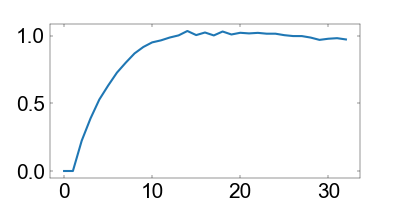

<IPython.core.display.Javascript object>


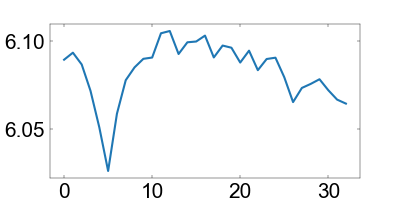

In [840]:
fig,ax = plt.subplots(figsize=(4,2))
ax.plot(y/1e3, popts[:,0]/2/np.pi)
fig,ax = plt.subplots(figsize=(4,2))
ax.plot(y/1e3, popts[:,1]/2/np.pi*np.sqrt(2))

<IPython.core.display.Javascript object>


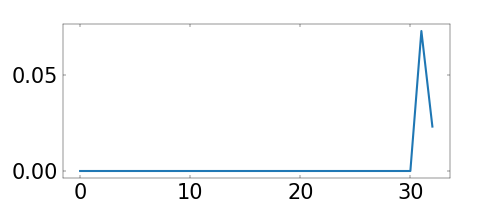

<IPython.core.display.Javascript object>


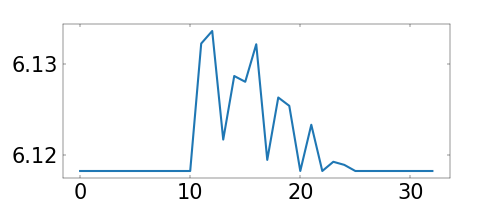

<IPython.core.display.Javascript object>


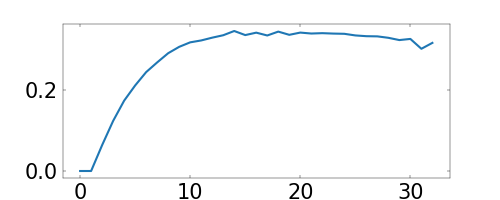

In [799]:
fig,ax = plt.subplots(figsize=(5,2))
ax.plot(y/1e3, popts2[:,0]/2/np.pi)
fig,ax = plt.subplots(figsize=(5,2))
ax.plot(y/1e3, popts2[:,1]/2/np.pi*np.sqrt(2))
fig,ax = plt.subplots(figsize=(5,2))
ax.plot(y/1e3, popts2[:,2]/2/np.pi)

<IPython.core.display.Javascript object>


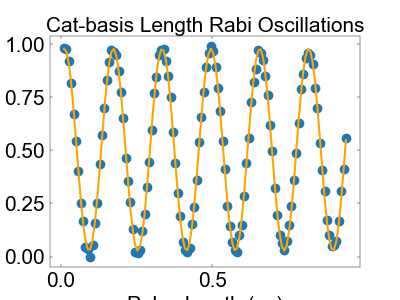

Omega_x = 6211.35 MHz


In [837]:
fig, ax = plt.subplots(figsize=(4,3))
ax.set_title("Cat-basis Length Rabi Oscillations")
ax.set_xlabel("Pulse length (ns)")
ax.set_ylabel("Signal (a.u.)")
x_pts = x
y_pts = z[0,:]
ax.scatter(x_pts, y_pts);

def sinRabi(x, a, T, phi, c):
    return a*np.sin(2*np.pi/T*x + phi) + c

guess = (1.2, 0.16, 0.5, 0.5)
popt,pcov = curve_fit(sinRabi, x_pts, y_pts, p0=guess)
ax.plot(x_pts, sinRabi(x_pts, *popt), color="orange")
print("Omega_x = %.2f MHz" % (1/popt[1]*1e3))

# Stark vs gain

In [11]:
dataLocation = "C:\\Users\\Hoang Le\\Dropbox (Princeton)\\QuantumRegister\\PersonalFolders\\Hoang\\KerrCatData\\220103_TAFC1_B3\\TAFC1_B3_quarterFlux_thruCav\\"

x_filename = 'qubitSpecStark_sweepStarkGain_freq_2022_01_16_07_19_41.csv'
x_address = dataLocation + x_filename
x_df = pd.read_csv(x_address, header=None)
x = np.array(x_df.values); x = x[0]

y_filename = 'qubitSpecStark_sweepStarkGain_starkgain_2022_01_16_07_19_41.csv'
y_address = dataLocation + y_filename
y_df = pd.read_csv(y_address, header=None)
y = np.array(y_df.values); y = y[0]

z_filename = 'qubitSpecStark_sweepStarkGain_results_2022_01_16_07_19_41.csv'
z_address = dataLocation + z_filename
z_df = pd.read_csv(z_address, header=None)
z = np.array(z_df.values); z = z[0]
z = z.reshape((len(y), len(x)))
z[9,np.argmin(z[9,:])] = z[9,np.argmin(z[9,:])-1]

<IPython.core.display.Javascript object>


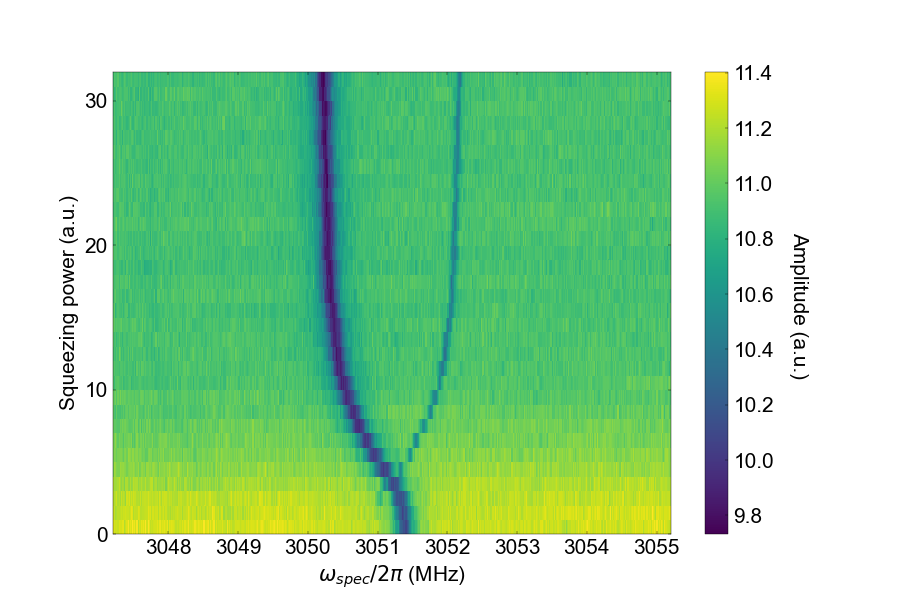

In [12]:
fig, ax = plt.subplots(figsize=(9,6))
im = ax.pcolormesh(x,y/1e3,z)
plt.colorbar(im)

# ax.set_xlabel('Probe frequency $\omega_{sp}$ (MHz)', fontsize=15, fontname="Arial")
# ax.set_title('Fixed $\omega_s = 2\omega_{01, sqz \: power=0}$', fontsize=15, fontname="Arial")
# s = "$Q_{int}$ = %.2f $\pm$ %.2fE6" % (Qint/1e6, Qint_err/1e6)
# ax.text(1, -31, s , fontsize=20, fontname="Arial")
plt.locator_params(axis='y', nbins=5)
# plt.locator_params(axis='x', nbins=5)
ax.tick_params(axis='both', which='major', labelsize=15)

# ax.vlines(x=3050.2, ymin = y.min(), ymax = y.max())
# ax.vlines(x=3051.4, ymin = y.min(), ymax = y.max())

ax.set_ylabel('Squeezing power (a.u.)', fontsize=15, fontname="Arial")
ax.set_xlabel(r'$\omega_{spec}/2\pi$ (MHz)', fontsize=15, fontname="Arial");
ax.tick_params(axis='both', which='major', labelsize=15);
plt.xticks(fontname = "Arial"); plt.yticks(fontname = "Arial");

s = "Amplitude (a.u.)"
ax.text(3056.9, 11, s , fontsize=15, fontname="Arial", rotation=270);
# plt.savefig("starkvsgain", dpi=600)

# ax.plot(x,z[32,:]-20)

<IPython.core.display.Javascript object>


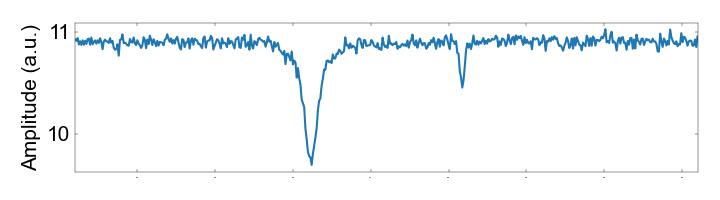

(3047.2, 3055.2)

In [13]:
fig,ax = plt.subplots(figsize=(7.2,2))
ax.plot(x,z[32,:])

ax.set_ylabel('Squeezing power (a.u.)', fontsize=15, fontname="Arial")

plt.locator_params(axis='y', nbins=1)
plt.locator_params(axis='x', nbins=9)
ax.tick_params(axis='both', which='major', labelsize=15)


ax.set_ylabel('Amplitude (a.u.)', fontsize=15, fontname="Arial")
# ax.set_xlabel(r'$\omega_{spec}/2\pi$ (MHz)', fontsize=15, fontname="Arial");
ax.tick_params(axis='x', which='major', labelsize=0);
plt.xticks(fontname = "Arial"); plt.yticks(fontname = "Arial");
plt.tight_layout()
ax.set_xlim((x.min(), x.max()))
# plt.savefig("starkvsgain_sqzpwr33", dpi=600)

<IPython.core.display.Javascript object>


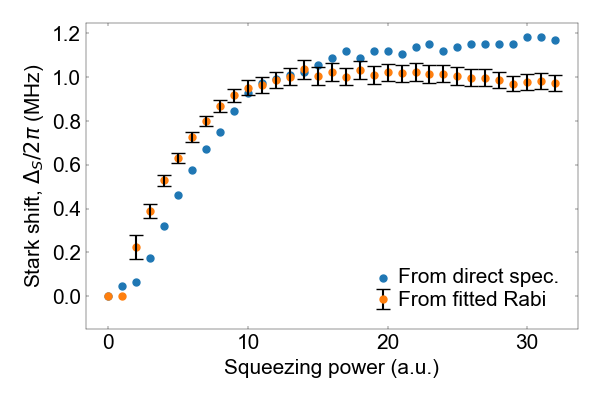

In [19]:
fList = []; xpts = y/1e3
for iii in range(len(y)):
    f_stark = x[np.argmin(z[iii,:])]
    fList.append(f_stark)
fList = np.array(fList)

y1 = fList.max()-fList;
y2 = starkfromrabi; y2Err = starkfromrabi_err;

fig,ax = plt.subplots(figsize=(6,4))
ax.scatter(xpts, y1, s=25, label="From direct spec.")
ax.scatter(xpts[0:2], y2[0:2], s=25, color='C1')
ax.errorbar(xpts[2:], y2[2:], y2Err[2:], ecolor='black', elinewidth=0, capsize=5, barsabove=True, linestyle=' ',
           marker='o', markersize=5, label="From fitted Rabi", color='C1')

def quad(x, a, b, c):
    return a*x**2 + b*x + c
end = 6; more = 3

popt1, pcov1 = curve_fit(quad, xpts[0:end], y1[0:end]); perr1 = np.sqrt(np.diag(pcov1))
# ax.plot(xpts[0:end+more], quad(xpts[0:end+more], *popt1), label="fit, from direct spec.", color='C0')

popt2, pcov2 = curve_fit(quad, xpts[0:end], y2[0:end]); perr2 = np.sqrt(np.diag(pcov2))
# ax.plot(xpts[0:end+more], quad(xpts[0:end+more], *popt2), label="fit, from fitted Rabi", color='C1')

plt.locator_params(axis='y', nbins=10)
plt.locator_params(axis='x', nbins=5)
ax.set_xlabel(r'Squeezing power (a.u.)', fontsize=15, fontname="Arial");
ax.set_ylabel(r'Stark shift, $\Delta_{S}/2\pi$ (MHz)', fontsize=15, fontname="Arial");
ax.tick_params(axis='both', which='major', labelsize=15);
plt.xticks(fontname = "Arial"); plt.yticks(fontname = "Arial");

ax.set_ylim((-0.15,1.25))

#get handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# #specify order of items in legend
# order = [2,0,3,1]

# #add legend to plot
# plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc="lower right", fontsize=12)
ax.legend()
plt.tight_layout()
# plt.savefig("rabi_fig4.svg", format='svg', dpi=900)

# g3 vs flux

In [15]:
dataLocation = "C:\\Users\\Hoang Le\\Dropbox (Princeton)\\QuantumRegister\\PersonalFolders\\Hoang\\KerrCatData\\220103_TAFC1_B3\\TAFC1_B3_quarterFlux_thruCav\\"

x_filename = 'g3.csv'
x_address = dataLocation + x_filename
x_df = pd.read_csv(x_address, header=None)
x = np.array(x_df.values); x=x[0];
xnew = [float(x[iii][1:-1]) for iii in range(len(x))]
g3 = np.array(xnew)

x_filename = 'anhar.csv'
x_address = dataLocation + x_filename
x_df = pd.read_csv(x_address, header=None)
y1 = np.array(x_df.values); y1 = y1[0]

x1 = np.linspace(-0.033,1.022,212)
x2 = np.linspace(0,1,200)

<IPython.core.display.Javascript object>


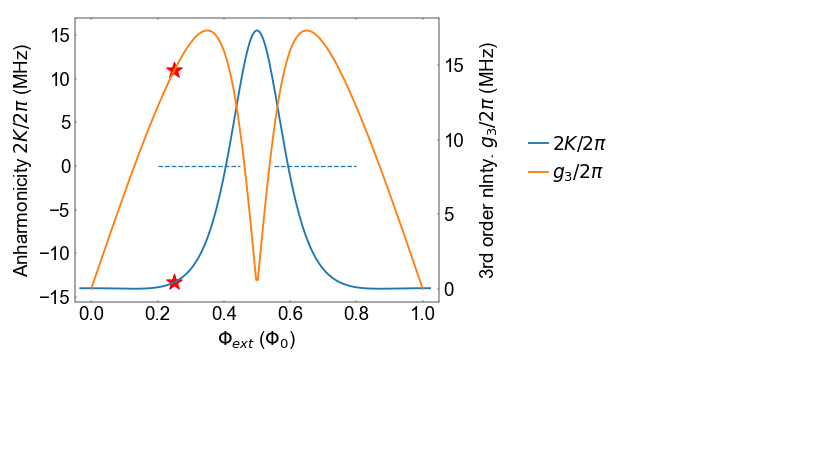

In [41]:
fig, ax = plt.subplots(figsize=(8.2,4.5))

ax.plot(x1, y1, label = r'$2K/2\pi$')

ax.set_ylabel(r'Anharmonicity $2K/2\pi$ (MHz)', fontsize=15, fontname="Arial")
ax.set_xlabel(r'$\Phi_{ext}$ ($\Phi_0$)', fontsize=15, fontname="Arial")
ax.tick_params(axis='both', which='major', labelsize=15)
plt.xticks(fontname = "Arial"); plt.yticks(fontname = "Arial")

ax.hlines(y=0, xmin=0.2, xmax=0.45, linestyle='--', linewidth=1, color='C0')
ax.hlines(y=0, xmin=0.55, xmax=0.8, linestyle='--', linewidth=1, color='C0')
ax.scatter(0.25, -13.264, s=169, color='red', marker="*")

ax.set_xlim([-0.05,1.05])
plt.tight_layout()

ax1 = ax.twinx()
ax1.plot(x2, g3, label = r'$g_3/2\pi$', color='C1')
ax1.set_ylabel(r'3rd order nlnty. $g_3/2\pi$ (MHz)', fontsize=15, fontname="Arial", labelpad=11)
ax1.scatter(0.25, 14.7, s=169, color='red', marker="*")

g4 = np.concatenate(([0,0,0,0,0,0],g3,[0,0,0,0,0,0]))
ax.legend(bbox_to_anchor=(1.2, 0.55, 0.1, 0.1), loc='upper left', fontsize=15)
ax1.legend(bbox_to_anchor=(1.2, 0.45, 0.1, 0.1), loc='upper left', fontsize=15)
plt.tight_layout()
# plt.savefig('anhar_g3_vsflux.png',dpi=600)

<IPython.core.display.Javascript object>


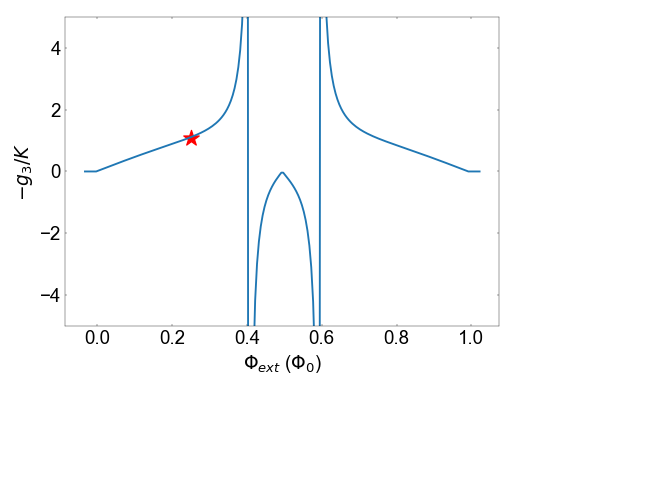

In [44]:
fig,ax = plt.subplots()
ax.plot(x1,-g4/y1)
ax.set_ylim((-5,5))

ax.set_ylabel(r'$-g_3/K$', fontsize=15, fontname="Arial")
ax.set_xlabel(r'$\Phi_{ext}$ ($\Phi_0$)', fontsize=15, fontname="Arial")
ax.tick_params(axis='both', which='major', labelsize=15)
plt.xticks(fontname = "Arial"); plt.yticks(fontname = "Arial")

ax.scatter(0.25, 1.1, s=169, color='red', marker="*")

plt.tight_layout()
# plt.savefig('g3overK_vsflux.png', dpi=600)

# Qubit spec

In [26]:
dataLocation = "C:\\Users\\Hoang Le\\Dropbox (Princeton)\\QuantumRegister\\PersonalFolders\\Hoang\\KerrCatData\\220103_TAFC1_B3\\TAFC1_B3_quarterFlux_thruCav\\"
dataLocation = "C:\\Users\\Hoang Le\\Dropbox (Princeton)\\QuantumRegister\\PersonalFolders\\Hoang\\KerrCatData\\220103_TAFC1_B3\\TAFC1_B3_quarterFlux_thruCL\\"

x_filename = 'qubitSpec_x_2022_01_07_17_59_13.csv'
x_filename = 'qubitSpec_x_2022_01_15_21_01_55.csv'
x_address = dataLocation + x_filename
x_df = pd.read_csv(x_address, header=None)
x = np.array(x_df.values); x = x[0]

y_filename = 'qubitSpec_y_2022_01_07_17_59_13.csv'
y_filename = 'qubitSpec_y_2022_01_15_21_01_55.csv'
y_address = dataLocation + y_filename
y_df = pd.read_csv(y_address, header=None)
y = np.array(y_df.values); y = y[0]

<IPython.core.display.Javascript object>


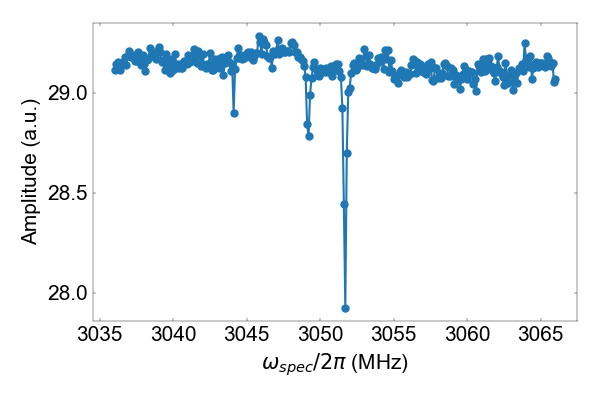

[3.06476408e+03 5.88484564e-01 1.91899431e-02 2.91284717e+01]


In [29]:
fig,ax = plt.subplots(figsize=(6,4))
ax.plot(x, y, label=r'$2\chi/2\pi$', color='C0', marker='o', markersize=5)

ax.set_ylabel(r'Amplitude (a.u.)', fontsize=15, fontname="Arial")
ax.set_xlabel(r'$\omega_{spec}/2\pi$ (MHz)', fontsize=15, fontname="Arial")
ax.tick_params(axis='both', which='major', labelsize=15)
plt.xticks(fontname = "Arial"); plt.yticks(fontname = "Arial")

def gaussian(x, x0, sig, a, c):
    return a*np.exp(-(x-x0)**2/2/sig**2) + c

    
p0=[3066, 1, 0.4,10.8]; 
lb = [-np.inf, 0, 0, -np.inf]; ub = [np.inf,np.inf,np.inf,np.inf]
popt, pcov = curve_fit(gaussian, x, y, p0=p0, bounds=(lb,ub)); perr = np.sqrt(np.diag(pcov));
print(popt)

# ax.plot(x, gaussian(x, *popt), color='orange', linewidth=3)

plt.locator_params(axis='y', nbins=5)
plt.locator_params(axis='x', nbins=10)
# ax.set_ylim((y.min()-0.02, 11.21))

plt.tight_layout()
# plt.savefig('qubitSpec1.png',dpi=600)

In [30]:
x = np.linspace(3030,3060,301)
y = np.linspace(20.26, 20.61, 301)

<IPython.core.display.Javascript object>


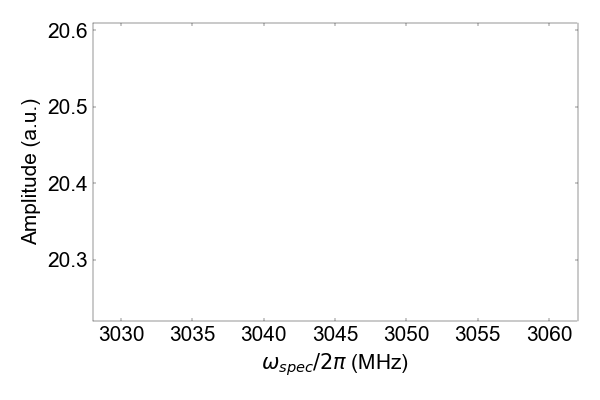

In [34]:
fig,ax = plt.subplots(figsize=(6,4))
# ax.plot(x, y, label=r'$2\chi/2\pi$', color='C0', marker='o', markersize=5)

ax.set_ylabel(r'Amplitude (a.u.)', fontsize=15, fontname="Arial")
ax.set_xlabel(r'$\omega_{spec}/2\pi$ (MHz)', fontsize=15, fontname="Arial")
ax.tick_params(axis='both', which='major', labelsize=15)
plt.xticks(fontname = "Arial"); plt.yticks(fontname = "Arial")

def gaussian(x, x0, sig, a, c):
    return a*np.exp(-(x-x0)**2/2/sig**2) + c

# ax.plot(x, gaussian(x, *popt), color='orange', linewidth=3)

plt.locator_params(axis='y', nbins=5)
plt.locator_params(axis='x', nbins=10)
ax.set_ylim((20.22, 20.61))
ax.set_xlim((3028, 3062))

plt.tight_layout()
# plt.savefig('qubitSpec2_fake.png',dpi=600)